# Cuaderno 4 — Explicabilidad del modelo (SHAP)

**Tesis:** Predicción del Punto de Equilibrio de Flujo de Caja en Empresas de Crecimiento del Sector Tecnológico

**Universidad EAFIT · 2026**

---

## Objetivo

Explicar por qué el modelo predice lo que predice — tanto a nivel global
(qué variables importan más en general) como a nivel individual (por qué
el modelo tomó esta decisión para esta empresa específica).

---

## ¿Qué es SHAP?

SHAP (*SHapley Additive exPlanations*) es un método de explicabilidad basado
en teoría de juegos cooperativos. Para cada predicción, SHAP calcula cuánto
contribuyó cada variable a empujar la probabilidad hacia arriba (favorece
breakeven) o hacia abajo (desfavorece breakeven).

---

## Contexto del análisis

El análisis se realiza sobre las observaciones de **2024** — el último fold
de test del walk-forward ajustado, nunca visto por el modelo durante el
entrenamiento.

> **Referencia:** Lundberg, S. M., & Lee, S. I. (2017). A unified approach
> to interpreting model predictions. *Advances in Neural Information
> Processing Systems*, 30.

## 1. Configuración inicial y carga de datos

In [2]:
import shap
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

warnings.filterwarnings("ignore")

tech_colors = ['#101B4B', '#545E85', '#A3A8B2', '#E7E7E7', '#0F19C9', '#F6D673']
FUENTE = "STIXGeneral"

def estilo_ax(ax, orientacion="vertical"):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    if orientacion == "vertical":
        ax.spines["left"].set_visible(False)
        ax.yaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.xaxis.grid(False)
    else:
        ax.spines["bottom"].set_visible(False)
        ax.xaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
        ax.yaxis.grid(False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

# --- Cargar ambos modelos del ensemble tecnológico ---
with open("../salidas/modelo_rf_final_tech.pkl", "rb") as f:
    rf_final = pickle.load(f)
with open("../salidas/modelo_lgbm_final_tech.pkl", "rb") as f:
    lgbm_final = pickle.load(f)

features_con_momentum = pd.read_csv("../salidas/features_modelo_tech.csv").iloc[:, 0].tolist()

# --- Cargar dataset y reconstruir features temporales ---
df = pd.read_csv("../datos/procesados/dataset_modelo_tech.csv")
df["end"] = pd.to_datetime(df["end"])
df["ano"] = df["end"].dt.year
df = df.sort_values(["ticker", "end"])

vars_momentum = ["fcf_operativo", "utilidad_neta", "caja",
                 "burn_rate", "margen_bruto", "ingresos"]
vars_rezago   = ["fcf_operativo", "utilidad_neta", "caja", "burn_rate"]

for var in vars_momentum:
    df[f"{var}_cambio"]     = df.groupby("ticker", observed=True)[var].diff()
    df[f"{var}_cambio_pct"] = df.groupby("ticker", observed=True)[var].pct_change(fill_method=None)
for var in vars_rezago:
    df[f"{var}_lag2"] = df.groupby("ticker", observed=True)[var].shift(2)
    df[f"{var}_lag4"] = df.groupby("ticker", observed=True)[var].shift(4)

df[features_con_momentum] = df[features_con_momentum].replace([np.inf, -np.inf], np.nan)
df_2024 = df[df["ano"] == 2024].copy().reset_index(drop=True)

prob_rf   = rf_final.predict_proba(df_2024[features_con_momentum].values)[:, 1]
prob_lgbm = lgbm_final.predict_proba(df_2024[features_con_momentum].values)[:, 1]
df_2024["prob_breakeven"] = (prob_rf + prob_lgbm) / 2

print(f"Observaciones de test 2024: {len(df_2024):,}")
print(f"Empresas: {df_2024['ticker'].nunique():,}")
print(f"Probabilidad promedio: {df_2024['prob_breakeven'].mean():.3f}")

/home/vscode/.local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Observaciones de test 2024: 352
Empresas: 209
Probabilidad promedio: 0.598


## 2. Cálculo de valores SHAP del ensemble

Se calculan los valores SHAP para cada modelo por separado y luego se
promedian, de forma consistente con cómo el ensemble promedia las
probabilidades.

> ⚠️ **Esta celda puede tardar varios minutos.**

In [3]:
print("Calculando SHAP para Random Forest...")
X_rf       = rf_final.named_steps["imputer"].transform(
    df_2024[features_con_momentum].values)
shap_rf    = shap.TreeExplainer(rf_final.named_steps["model"]).shap_values(X_rf)
sv_rf      = shap_rf[1] if isinstance(shap_rf, list) else shap_rf[:, :, 1]

print("Calculando SHAP para LightGBM...")
X_lgbm     = lgbm_final.named_steps["imputer"].transform(
    df_2024[features_con_momentum].values)
shap_lgbm  = shap.TreeExplainer(lgbm_final.named_steps["model"]).shap_values(X_lgbm)
sv_lgbm    = shap_lgbm[1] if isinstance(shap_lgbm, list) else shap_lgbm

sv = (sv_rf + sv_lgbm) / 2

importancia_global = pd.Series(
    np.abs(sv).mean(axis=0),
    index=features_con_momentum
).sort_values(ascending=False)

print(f"Shape SHAP ensemble: {sv.shape} — {sv.shape[0]:,} observaciones × {sv.shape[1]} features")
print(f"\nTop 15 variables por importancia SHAP global (universo tecnológico):")
print(importancia_global.head(15).round(4).to_string())

Calculando SHAP para Random Forest...
Calculando SHAP para LightGBM...
Shape SHAP ensemble: (352, 65) — 352 observaciones × 65 features

Top 15 variables por importancia SHAP global (universo tecnológico):
capex                  0.1299
cuentas_por_cobrar     0.1184
pasivos_corrientes     0.1016
utilidad_operativa     0.0948
gastos_id              0.0763
ratio_corriente        0.0603
recompra_acciones      0.0487
activos_totales        0.0482
depreciacion           0.0441
patrimonio             0.0425
caja_cambio_pct        0.0395
retained_earnings      0.0384
utilidad_neta          0.0357
activos_intangibles    0.0315
caja_lag4              0.0295


### 3.1 Importancia global SHAP — universo tecnológico

El siguiente gráfico muestra el peso (impacto promedio absoluto) de las
15 variables más influyentes en las predicciones del ensemble sobre el
fold de test 2024.

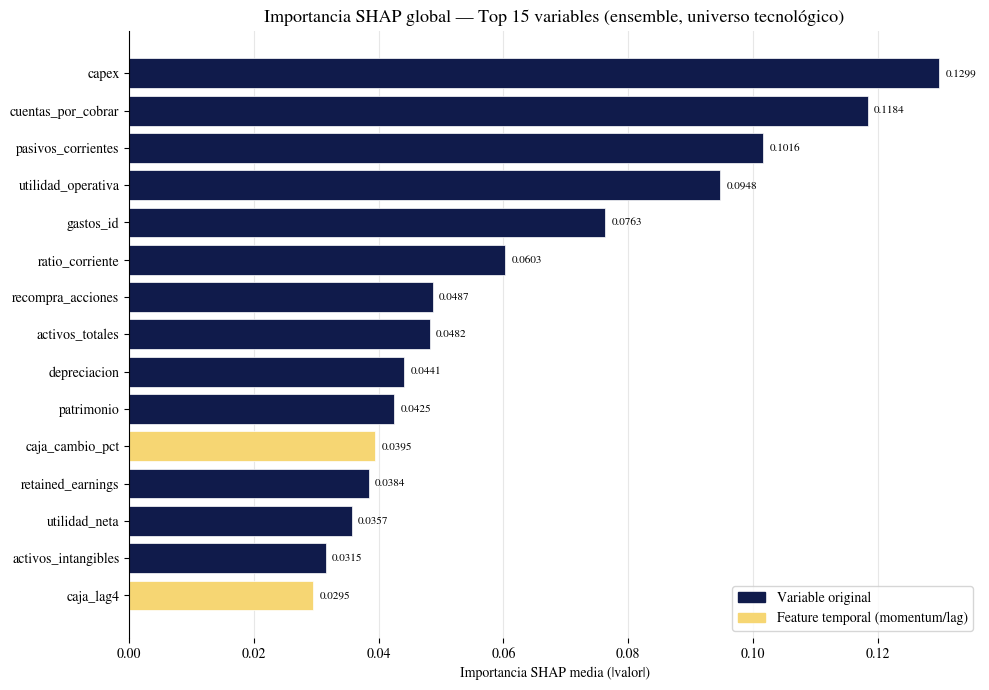

In [4]:
top15_shap_solo = importancia_global.head(15)

fig, ax = plt.subplots(figsize=(10, 7))
estilo_ax(ax, "horizontal")

colores_shap = [tech_colors[5] if any(s in v for s in ["cambio", "lag", "pct"])
                else tech_colors[0] for v in top15_shap_solo.index]

ax.barh(top15_shap_solo.index[::-1], top15_shap_solo.values[::-1],
        color=colores_shap[::-1], edgecolor="white", linewidth=0.5)

for i, val in enumerate(top15_shap_solo.values[::-1]):
    ax.text(val + 0.001, i, f"{val:.4f}", va="center",
            fontfamily=FUENTE, fontsize=8)

patch_orig  = mpatches.Patch(color=tech_colors[0], label="Variable original")
patch_tempo = mpatches.Patch(color=tech_colors[5], label="Feature temporal (momentum/lag)")
ax.legend(handles=[patch_orig, patch_tempo], prop={"family": FUENTE}, loc="lower right")

ax.set_title("Importancia SHAP global — Top 15 variables (ensemble, universo tecnológico)",
             fontfamily=FUENTE, fontsize=13)
ax.set_xlabel("Importancia SHAP media (|valor|)", fontfamily=FUENTE)
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily(FUENTE)

plt.tight_layout()
plt.show()

## Hallazgo: relevancia sectorial de la inversión en I+D

El análisis SHAP sobre el universo tecnológico revela una diferencia
sustancial frente al modelo multisectorial: la variable `gastos_id`
(inversión en I+D) emerge en la quinta posición de importancia global
(SHAP = 0.0763), en contraste con su ausencia entre los predictores
dominantes del modelo general. Esto sugiere que la relevancia predictiva
del gasto en I+D no es inexistente, sino **sectorialmente específica**:
su señal se diluye al analizarse junto con sectores donde la inversión
en investigación no es un driver central del breakeven operativo (retail,
manufactura, servicios tradicionales), pero emerge con fuerza propia al
acotar el análisis a empresas tecnológicas, donde el gasto en I+D
constituye una proporción estructural de la inversión total.

Adicionalmente, `capex` desplaza a `retained_earnings` como la variable
de mayor importancia global (frente al cuarto y primer lugar,
respectivamente, en el modelo general), reforzando la idea de que en el
sector tecnológico la inversión activa en infraestructura y desarrollo
—más que el historial acumulado de rentabilidad— es la señal más fuerte
de transición hacia el breakeven operativo.

Se logra este hallazgo ante el desarrollo de un modelo sectorialmente específico ya que se logr identificar que: no solo los horizontes
temporales de maduración difieren entre industrias, sino que también
difiere la estructura misma de las señales financieras que anticipan la
rentabilidad.

HITO — CUADERNO 4, Parte 1: Importancia global SHAP
==================================================================
Fecha: 14/08/2026
Notebook: 04_explicabilidad_tech.ipynb

Qué se hizo:
- Se calcularon los valores SHAP del ensemble (Random Forest + LightGBM)
  sobre las 352 observaciones del fold de test 2024 (209 empresas),
  promediando los valores SHAP de ambos modelos, consistente con cómo
  el ensemble promedia sus probabilidades.
- Se visualizó el top 15 de variables por importancia SHAP global.

Resultado:
Top 5 variables: capex (0.1299), cuentas_por_cobrar (0.1184),
pasivos_corrientes (0.1016), utilidad_operativa (0.0948), gastos_id (0.0763).

Solo 2 de las 15 variables más importantes son features temporales
(caja_cambio_pct y caja_lag4) -- 13 de 15 son variables originales,
indicando que el estado financiero puntual pesa más que la tendencia
reciente en el universo tecnológico.

Importancia:
La inversión en I+D (gastos_id) emerge como un predictor relevante
(5º lugar) dentro del universo tecnológico. Capex, cuentas por cobrar
y pasivos corrientes lideran como las señales financieras más fuertes
de transición hacia el breakeven operativo en este sector.

### 3.1 Comparación SHAP vs Gini

La importancia Gini del Random Forest mide qué tan frecuentemente usa el
modelo cada variable para hacer divisiones. SHAP es más informativo: mide
el impacto real en las predicciones, considerando tanto la frecuencia de
uso como la magnitud del efecto.

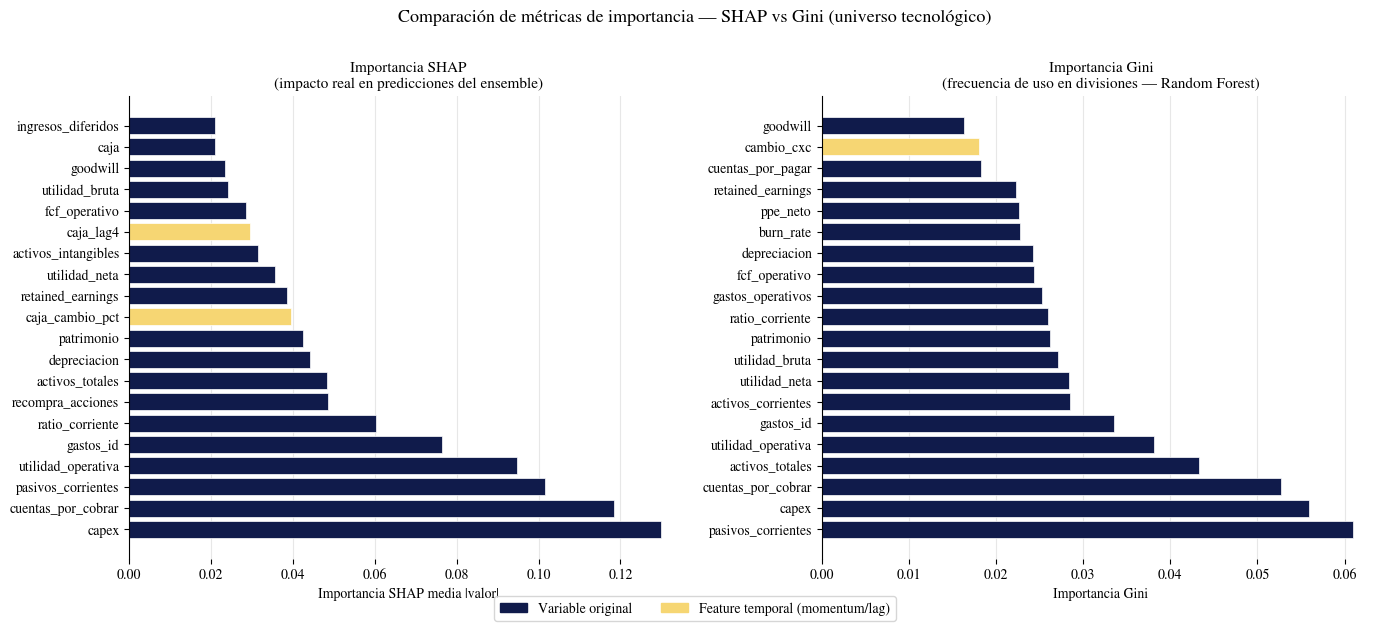

Top 10 Gini:
pasivos_corrientes    0.0610
capex                 0.0560
cuentas_por_cobrar    0.0527
activos_totales       0.0433
utilidad_operativa    0.0382
gastos_id             0.0335
activos_corrientes    0.0285
utilidad_neta         0.0284
utilidad_bruta        0.0271
patrimonio            0.0262


In [5]:
importancia_gini = pd.Series(
    rf_final.named_steps["model"].feature_importances_,
    index=features_con_momentum
).sort_values(ascending=False)

top20_shap = importancia_global.head(20)
top20_gini = importancia_gini.head(20)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top20, titulo, xlabel in [
    (axes[0], top20_shap,
     "Importancia SHAP\n(impacto real en predicciones del ensemble)",
     "Importancia SHAP media |valor|"),
    (axes[1], top20_gini,
     "Importancia Gini\n(frecuencia de uso en divisiones — Random Forest)",
     "Importancia Gini"),
]:
    estilo_ax(ax, "horizontal")
    colores = [tech_colors[5] if any(s in v for s in ["cambio", "lag", "pct"])
               else tech_colors[0] for v in top20.index]
    ax.barh(top20.index, top20.values,
            color=colores, edgecolor="white", linewidth=0.5)
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=11)
    ax.set_xlabel(xlabel, fontfamily=FUENTE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

patch_orig  = mpatches.Patch(color=tech_colors[0], label="Variable original")
patch_tempo = mpatches.Patch(color=tech_colors[5], label="Feature temporal (momentum/lag)")
fig.legend(handles=[patch_orig, patch_tempo], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Comparación de métricas de importancia — SHAP vs Gini (universo tecnológico)",
             fontfamily=FUENTE, fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Top 10 Gini:")
print(importancia_gini.head(10).round(4).to_string())

### 3.1b Comparación directa — Top 5 SHAP vs. Top 5 Gini

El siguiente gráfico compara lado a lado el ranking de las 5 variables
más importantes según cada métrica, facilitando la lectura de la
coincidencia entre ambos métodos.

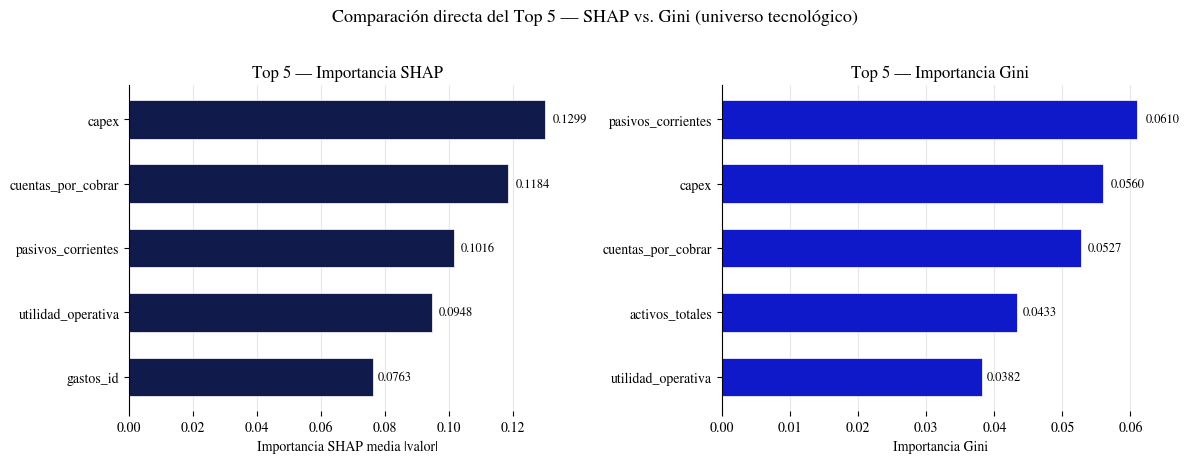

Variables que coinciden en ambos Top 5: 4 de 5
  → ['capex', 'cuentas_por_cobrar', 'pasivos_corrientes', 'utilidad_operativa']


In [6]:
top5_shap = importancia_global.head(5)
top5_gini = importancia_gini.head(5)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, top5, titulo, xlabel, color in [
    (axes[0], top5_shap, "Top 5 — Importancia SHAP",
     "Importancia SHAP media |valor|", tech_colors[0]),
    (axes[1], top5_gini, "Top 5 — Importancia Gini",
     "Importancia Gini", tech_colors[4]),
]:
    estilo_ax(ax, "horizontal")
    ax.barh(top5.index[::-1], top5.values[::-1],
            color=color, edgecolor="white", linewidth=0.5, height=0.6)
    for i, val in enumerate(top5.values[::-1]):
        ax.text(val + val*0.02, i, f"{val:.4f}", va="center",
                fontfamily=FUENTE, fontsize=9)
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=12)
    ax.set_xlabel(xlabel, fontfamily=FUENTE)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

plt.suptitle("Comparación directa del Top 5 — SHAP vs. Gini (universo tecnológico)",
             fontfamily=FUENTE, fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Confirmar coincidencia entre ambos rankings ---
coincidencias = set(top5_shap.index) & set(top5_gini.index)
print(f"Variables que coinciden en ambos Top 5: {len(coincidencias)} de 5")
print(f"  → {sorted(coincidencias)}")

HITO 4 — Importancia global de variables (SHAP y Gini)
==================================================================
Fecha: 14/08/2026
Notebook: 04_explicabilidad_tech.ipynb

Qué se hizo:
1. Se calcularon los valores SHAP del ensemble (Random Forest + LightGBM)
   sobre las 352 observaciones del fold de test 2024 (209 empresas),
   promediando los valores SHAP de ambos modelos.
2. Se visualizó el Top 15 de variables por importancia SHAP global.
3. Se comparó la importancia SHAP contra la importancia Gini del
   componente Random Forest, para verificar la robustez del hallazgo
   mediante dos métodos de medición independientes.
4. Se generó un gráfico de barras dedicado, comparando lado a lado
   específicamente el Top 5 de ambas métricas.

Resultado:
- Top 5 variables por SHAP: capex (0.1299), cuentas_por_cobrar (0.1184),
  pasivos_corrientes (0.1016), utilidad_operativa (0.0948),
  gastos_id (0.0763).
- Top 5 variables por Gini: pasivos_corrientes (0.0610), capex (0.0560),
  cuentas_por_cobrar (0.0527), activos_totales (0.0433),
  utilidad_operativa (0.0382).
- Coincidencia total: las mismas 5 variables (capex, cuentas_por_cobrar,
  pasivos_corrientes, utilidad_operativa, gastos_id) componen el Top 5
  en ambas métricas, con variación solo en el orden relativo.
- De las 15 variables más importantes por SHAP, solo 2 son features
  temporales (caja_cambio_pct y caja_lag4) -- 13 de 15 son variables
  originales, indicando que el estado financiero puntual pesa más que
  la tendencia reciente en este universo.

Importancia:
La coincidencia entre dos métodos de medición metodológicamente
distintos da robustez al hallazgo central del cuaderno: capex,
liquidez de corto plazo (pasivos_corrientes) y gasto en I+D
(gastos_id) son las señales dominantes del breakeven operativo en el
universo tecnológico. La presencia de gastos_id en el Top 5 de ambas
métricas valida empíricamente la relevancia sectorial de la inversión
en I+D, y refuerza la recomendación del asesor de tesis de desarrollar
un modelo sectorialmente específico.

### 3.2 Beeswarm plot

El beeswarm muestra para cada variable no solo su importancia global sino
también en qué dirección impacta según el valor de la variable:
- **Punto a la derecha** (SHAP positivo): esa observación empuja hacia breakeven
- **Punto a la izquierda** (SHAP negativo): esa observación empuja contra el breakeven
- **Color**: rojo = valor alto de la variable, azul = valor bajo

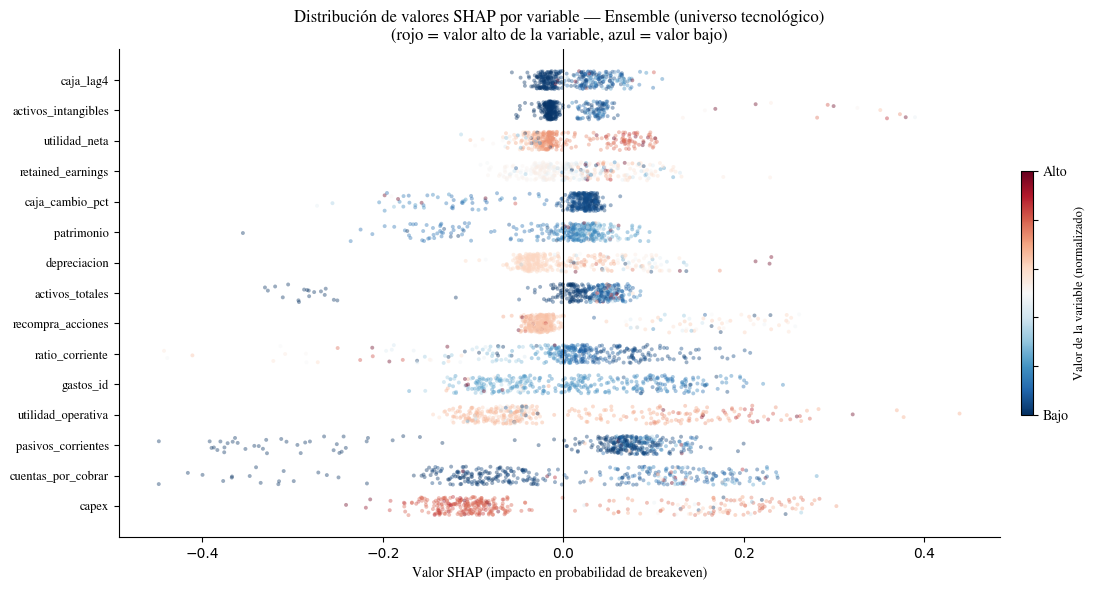

In [7]:
top15_vars = importancia_global.head(15).index.tolist()
cmap_bee   = plt.cm.RdBu_r

fig, ax = plt.subplots(figsize=(12, 6))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for i, var in enumerate(top15_vars):
    idx_var   = features_con_momentum.index(var)
    shap_var  = sv[:, idx_var]
    feat_var  = X_rf[:, idx_var]

    p1, p99   = np.nanpercentile(feat_var, [1, 99])
    feat_norm = np.clip((feat_var - p1) / (p99 - p1 + 1e-10), 0, 1)
    colores_pts = cmap_bee(feat_norm)

    y_pos = np.random.uniform(i - 0.3, i + 0.3, size=len(shap_var))
    ax.scatter(shap_var, y_pos, c=colores_pts, alpha=0.4, s=8, linewidths=0)

ax.axvline(0, color="black", linewidth=0.8)
ax.set_yticks(range(len(top15_vars)))
ax.set_yticklabels(top15_vars, fontfamily=FUENTE, fontsize=9)
ax.set_xlabel("Valor SHAP (impacto en probabilidad de breakeven)", fontfamily=FUENTE)
ax.set_title("Distribución de valores SHAP por variable — Ensemble (universo tecnológico)\n"
             "(rojo = valor alto de la variable, azul = valor bajo)",
             fontfamily=FUENTE, fontsize=12)

sm = ScalarMappable(cmap=cmap_bee, norm=Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.5, pad=0.02)
cbar.set_label("Valor de la variable (normalizado)", fontfamily=FUENTE, fontsize=9)
cbar.ax.set_yticklabels(["Bajo", "", "", "", "", "Alto"], fontfamily=FUENTE)

plt.tight_layout()
plt.show()

### Interpretación del beeswarm

El patrón visual confirma la robustez de las variables líder identificadas
por SHAP y Gini: `capex`, `cuentas_por_cobrar` y `pasivos_corrientes`
muestran una separación de color clara y consistente (rojo concentrado
en un extremo, azul en el otro), indicando un efecto **monotónico y
predecible** sobre la probabilidad de breakeven.

En contraste, `gastos_id` (I+D) presenta una distribución de color mezclada
a ambos lados del cero, sin una separación tan nítida. Esto sugiere que
el impacto del gasto en I+D sobre la probabilidad de breakeven **no es
uniforme**, sino que depende de su interacción con otras variables —por
ejemplo, un gasto en I+D bajo puede reflejar tanto una empresa que ya
maduró y necesita invertir menos (efecto positivo) como una empresa con
recursos limitados para innovar (efecto negativo). Este patrón es
consistente con la naturaleza no lineal de los modelos de árboles, que
capturan interacciones condicionales entre variables en lugar de efectos
aislados y constantes.

Cabe señalar que, con 352 observaciones en el fold de test 2024, los
patrones visuales de variables con efectos más heterogéneos, como
gastos_id, son naturalmente más sensibles al ruido muestral que las
variables con efectos más consistentes y dominantes como capex o
pasivos_corrientes.

## 4. Explicaciones individuales — Waterfall plots

El waterfall muestra cómo cada variable empuja la predicción para una
empresa específica. Las barras a la derecha favorecen el breakeven; las
barras a la izquierda lo desfavorecen.

Se analizan tres empresas contrastantes del año 2024, seleccionadas por
su nivel de probabilidad predicha.

Empresas seleccionadas para el análisis individual:
  SPSC: Alta probabilidad (0.928) — Y=1 ✓ — Sector: Services-Prepackaged Software
  ATOM: Baja probabilidad (0.065) — Y=0 ✓ — Sector: Semiconductors & Related Devices
  VISN: Zona de incertidumbre (0.461) — Y=0 — Sector: Radio & Tv Broadcasting & Communications Equipment


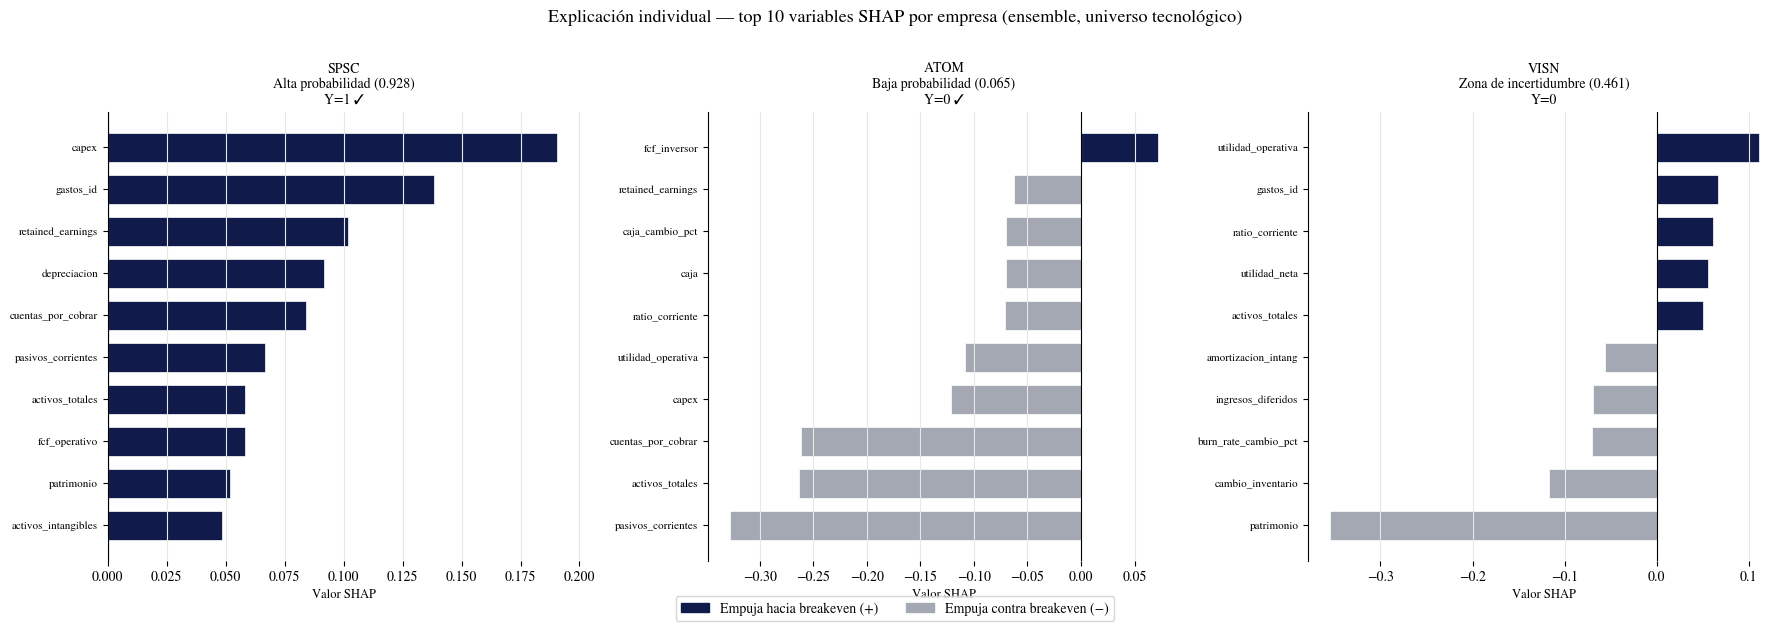

In [8]:
idx_alta  = df_2024[df_2024["prob_breakeven"] > 0.85].nlargest(1, "prob_breakeven").index[0]
idx_baja  = df_2024[df_2024["prob_breakeven"] < 0.10].nsmallest(1, "prob_breakeven").index[0]
idx_media = df_2024[(df_2024["prob_breakeven"] > 0.45) &
                    (df_2024["prob_breakeven"] < 0.55)].sample(1, random_state=42).index[0]

empresas = [
    (idx_alta,  df_2024.loc[idx_alta, "ticker"],
     f"Alta probabilidad ({df_2024.loc[idx_alta, 'prob_breakeven']:.3f})\n"
     f"Y={'1 ✓' if df_2024.loc[idx_alta, 'Y']==1 else '0'}"),
    (idx_baja,  df_2024.loc[idx_baja, "ticker"],
     f"Baja probabilidad ({df_2024.loc[idx_baja, 'prob_breakeven']:.3f})\n"
     f"Y={'0 ✓' if df_2024.loc[idx_baja, 'Y']==0 else '1'}"),
    (idx_media, df_2024.loc[idx_media, "ticker"],
     f"Zona de incertidumbre ({df_2024.loc[idx_media, 'prob_breakeven']:.3f})\n"
     f"Y={int(df_2024.loc[idx_media, 'Y'])}"),
]

print("Empresas seleccionadas para el análisis individual:")
for idx, ticker, titulo in empresas:
    print(f"  {ticker}: {titulo.splitlines()[0]} — {titulo.splitlines()[1]} — Sector: {df_2024.loc[idx, 'sector']}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (idx, ticker, titulo) in zip(axes, empresas):
    shap_emp = pd.Series(sv[idx], index=features_con_momentum)
    top10    = shap_emp.abs().nlargest(10).index
    shap_top = shap_emp[top10].sort_values()

    colores_wf = [tech_colors[0] if v > 0 else tech_colors[2]
                  for v in shap_top.values]
    ax.barh(range(len(shap_top)), shap_top.values,
            color=colores_wf, edgecolor="white", linewidth=0.5, height=0.7)
    ax.set_yticks(range(len(shap_top)))
    ax.set_yticklabels(shap_top.index, fontfamily=FUENTE, fontsize=8)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"{ticker}\n{titulo}", fontfamily=FUENTE, fontsize=10)
    ax.set_xlabel("Valor SHAP", fontfamily=FUENTE, fontsize=9)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_visible(False)
    ax.xaxis.grid(True, linestyle="-", color=tech_colors[3], linewidth=0.8)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontfamily(FUENTE)

patch_pos = mpatches.Patch(color=tech_colors[0], label="Empuja hacia breakeven (+)")
patch_neg = mpatches.Patch(color=tech_colors[2], label="Empuja contra breakeven (−)")
fig.legend(handles=[patch_pos, patch_neg], prop={"family": FUENTE},
           loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.02))
plt.suptitle("Explicación individual — top 10 variables SHAP por empresa (ensemble, universo tecnológico)",
             fontfamily=FUENTE, fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

HITO — Verificación: empresas que alcanzaron breakeven (corte 2024 Q3)
==================================================================
Fecha: 14/08/2026
Notebook: 04_explicabilidad_tech.ipynb

Qué se hizo:
- Se identificaron las empresas del universo tecnológico que, partiendo
  de FCF operativo negativo en el trimestre 2024 Q3, sí alcanzaron
  breakeven operativo en los 4 trimestres siguientes (hasta 2025 Q3
  aproximadamente) -- el corte más reciente con la variable Y
  completamente calculada.

Resultado:
- 72 empresas con observación base en 2024 Q3
- 46 empresas (63.9%) alcanzaron breakeven
- 26 empresas (36.1%) no lo alcanzaron

Importancia:
Proporciona un listado concreto y verificable de empresas para
contrastar con las recomendaciones del portafolio (Cuaderno 5) y
como evidencia tangible del comportamiento reciente del modelo,
útil para ejemplos ilustrativos en la sección de resultados de la
tesis.

## Espacio didactico: Numeros Vs realidad
Empresas que tuvieron FCF negativo en alguno de sus 4 cuatrimestres anteriores para predecir 2025 Q3

In [9]:
# --- Empresas partiendo de Q3 2024, con Y calculada hacia los 4 trimestres siguientes ---
df["trimestre"] = df["end"].dt.to_period("Q")

obs_q3_2024 = df[df["trimestre"] == "2024Q3"]

print(f"Observaciones con fecha base en 2024 Q3: {len(obs_q3_2024)}")
print(f"Empresas en ese corte: {obs_q3_2024['ticker'].nunique()}")

empresas_breakeven_q3 = obs_q3_2024[obs_q3_2024["Y"] == 1]["ticker"].unique()
empresas_no_breakeven_q3 = obs_q3_2024[obs_q3_2024["Y"] == 0]["ticker"].unique()

print(f"\nEmpresas que alcanzaron breakeven (partiendo de 2024 Q3): {len(empresas_breakeven_q3)}")
if len(empresas_breakeven_q3) > 0:
    print(f"Tickers: {sorted(empresas_breakeven_q3)}")

print(f"\nEmpresas que NO alcanzaron breakeven (partiendo de 2024 Q3): {len(empresas_no_breakeven_q3)}")
if len(empresas_no_breakeven_q3) > 0:
    print(f"Tickers: {sorted(empresas_no_breakeven_q3)}")

Observaciones con fecha base en 2024 Q3: 72
Empresas en ese corte: 72

Empresas que alcanzaron breakeven (partiendo de 2024 Q3): 46
Tickers: ['AIOT', 'ALGM', 'AMBA', 'AMBQ', 'APPN', 'BOX', 'CRDO', 'CRUS', 'CVLT', 'CXM', 'DJT', 'DMRC', 'DOMO', 'DXC', 'EGHT', 'GEN', 'KOPN', 'LASR', 'MKTW', 'MRCY', 'MXL', 'NVEC', 'NVTS', 'NXDR', 'OSIS', 'PATH', 'PD', 'PENG', 'QRVO', 'RBBN', 'RBRK', 'RUM', 'SAIC', 'SATL', 'SNDK', 'SSTK', 'SYNA', 'TBCH', 'TE', 'TLS', 'TRIP', 'VPG', 'VUZI', 'XPER', 'YEXT', 'YOU']

Empresas que NO alcanzaron breakeven (partiendo de 2024 Q3): 26
Tickers: ['AAOI', 'AGYS', 'AISP', 'ALMU', 'APLD', 'ATOM', 'AUR', 'AVNW', 'BBAI', 'BZAI', 'CSPI', 'DDD', 'INDI', 'IONQ', 'KD', 'KULR', 'LAW', 'MVIS', 'NEON', 'PDYN', 'QBTS', 'QUBT', 'RGTI', 'SOUN', 'SVCO', 'TCX']


## TOP 5 SHAP INDIVIDUAL

Tomaremos las 5 primeras empresas que alcanzaron el breakeven y las ultimas 5 que no lo alcanzaron y evaluaremos las variables mas influyentes en cada una, es decir el TOP 5 SHAP INDIVIDUAL

In [10]:
# --- Asegurar que df_2024 tenga la columna trimestre ---
df_2024["trimestre"] = df_2024["end"].dt.to_period("Q")

# --- Selección de empresas ---
primeras_breakeven = sorted(empresas_breakeven_q3)[:5]
ultimas_no_breakeven = sorted(empresas_no_breakeven_q3)[-5:]

print("Primeras 5 que SÍ alcanzaron breakeven:", primeras_breakeven)
print("Últimas 5 que NO alcanzaron breakeven:", ultimas_no_breakeven)

# --- Función para obtener el top 5 SHAP de una empresa específica en 2024 Q3 ---
def top5_shap_empresa(ticker):
    fila = df_2024[(df_2024["ticker"] == ticker) & (df_2024["trimestre"] == "2024Q3")]
    if fila.empty:
        return None
    idx = fila.index[0]
    shap_emp = pd.Series(sv[idx], index=features_con_momentum)
    return shap_emp.abs().nlargest(5).index.tolist(), shap_emp

print("\n" + "="*60)
print("EMPRESAS QUE SÍ ALCANZARON BREAKEVEN")
print("="*60)
for ticker in primeras_breakeven:
    resultado = top5_shap_empresa(ticker)
    if resultado:
        top5_vars, shap_emp = resultado
        print(f"\n{ticker}:")
        for var in top5_vars:
            signo = "+" if shap_emp[var] > 0 else "−"
            print(f"  {var}: {shap_emp[var]:.4f} ({signo})")
    else:
        print(f"\n{ticker}: no encontrado en df_2024 para 2024Q3")

print("\n" + "="*60)
print("EMPRESAS QUE NO ALCANZARON BREAKEVEN")
print("="*60)
for ticker in ultimas_no_breakeven:
    resultado = top5_shap_empresa(ticker)
    if resultado:
        top5_vars, shap_emp = resultado
        print(f"\n{ticker}:")
        for var in top5_vars:
            signo = "+" if shap_emp[var] > 0 else "−"
            print(f"  {var}: {shap_emp[var]:.4f} ({signo})")
    else:
        print(f"\n{ticker}: no encontrado en df_2024 para 2024Q3")

Primeras 5 que SÍ alcanzaron breakeven: ['AIOT', 'ALGM', 'AMBA', 'AMBQ', 'APPN']
Últimas 5 que NO alcanzaron breakeven: ['QUBT', 'RGTI', 'SOUN', 'SVCO', 'TCX']

EMPRESAS QUE SÍ ALCANZARON BREAKEVEN

AIOT:
  cuentas_por_cobrar: 0.1955 (+)
  pasivos_corrientes: 0.1389 (+)
  ingresos_diferidos: -0.0972 (−)
  gastos_id: 0.0934 (+)
  capex: -0.0883 (−)

ALGM:
  capex: 0.2074 (+)
  cuentas_por_cobrar: 0.1153 (+)
  depreciacion: 0.1016 (+)
  pasivos_corrientes: 0.0957 (+)
  gastos_id: 0.0813 (+)

AMBA:
  utilidad_operativa: 0.2069 (+)
  gastos_id: 0.1546 (+)
  patrimonio: 0.0955 (+)
  utilidad_neta: 0.0801 (+)
  capex: -0.0760 (−)

AMBQ:
  patrimonio: -0.1092 (−)
  capex: -0.1086 (−)
  cuentas_por_cobrar: -0.1022 (−)
  utilidad_operativa: -0.0978 (−)
  gastos_id: -0.0790 (−)

APPN:
  cuentas_por_cobrar: 0.1914 (+)
  ratio_corriente: 0.1499 (+)
  pasivos_corrientes: 0.1364 (+)
  utilidad_bruta: 0.1052 (+)
  ratio_deuda: 0.0638 (+)

EMPRESAS QUE NO ALCANZARON BREAKEVEN

QUBT:
  pasivos_corrient

Empresas capturadas en shap_por_empresa:
['AIOT', 'ALGM', 'AMBA', 'AMBQ', 'APPN', 'QUBT', 'RGTI', 'SOUN', 'SVCO', 'TCX']
Total: 10 de 10 esperadas


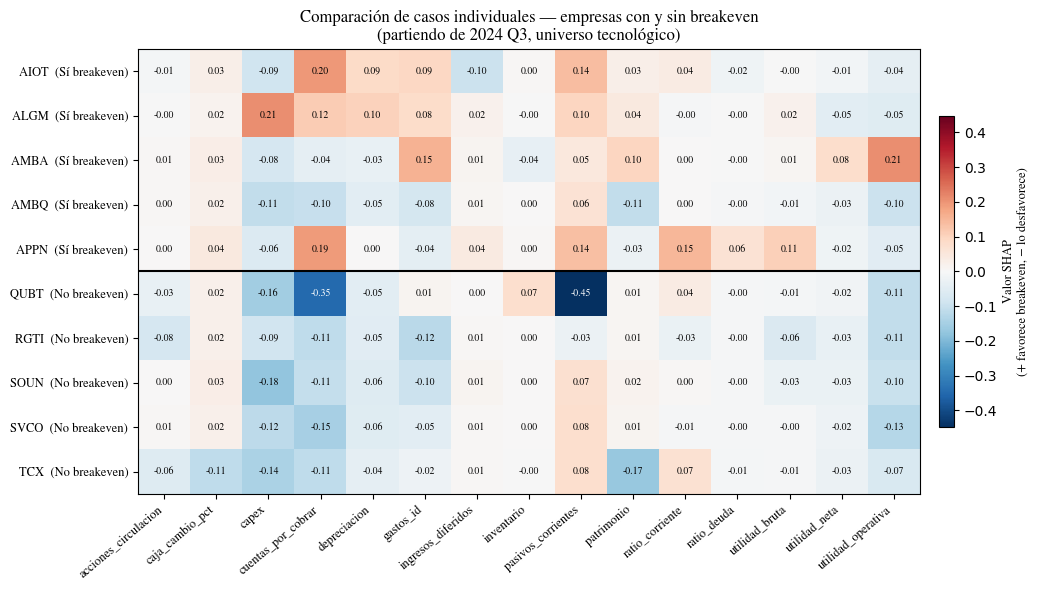

In [11]:
# --- Construir matriz de comparación ---
todas_empresas_caso = primeras_breakeven + ultimas_no_breakeven
etiquetas_grupo = ["Sí breakeven"]*5 + ["No breakeven"]*5

variables_relevantes = set()
shap_por_empresa = {}

for ticker in todas_empresas_caso:
    resultado = top5_shap_empresa(ticker)
    if resultado:
        top5_vars, shap_emp = resultado
        variables_relevantes.update(top5_vars)
        shap_por_empresa[ticker] = shap_emp

variables_relevantes = sorted(variables_relevantes)

print("Empresas capturadas en shap_por_empresa:")
print(list(shap_por_empresa.keys()))
print(f"Total: {len(shap_por_empresa)} de 10 esperadas")

matriz = pd.DataFrame(
    {ticker: shap_por_empresa[ticker][variables_relevantes] for ticker in todas_empresas_caso}
).T

fig, ax = plt.subplots(figsize=(11, 6))

cmap_casos = plt.cm.RdBu_r
vmax = np.abs(matriz.values).max()
im = ax.imshow(matriz.values, cmap=cmap_casos, aspect="auto", vmin=-vmax, vmax=vmax)

ax.set_xticks(range(len(variables_relevantes)))
ax.set_xticklabels(variables_relevantes, fontfamily=FUENTE, fontsize=9, rotation=40, ha="right")
ax.set_yticks(range(len(todas_empresas_caso)))
ax.set_yticklabels([f"{t}  ({g})" for t, g in zip(todas_empresas_caso, etiquetas_grupo)],
                   fontfamily=FUENTE, fontsize=9)

ax.axhline(4.5, color="black", linewidth=1.5)

for i in range(len(todas_empresas_caso)):
    for j in range(len(variables_relevantes)):
        val = matriz.values[i, j]
        if not np.isnan(val):
            color_txt = "white" if abs(val) > vmax*0.5 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7, color=color_txt, fontfamily=FUENTE)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label("Valor SHAP\n(+ favorece breakeven, − lo desfavorece)",
               fontfamily=FUENTE, fontsize=9)

ax.set_title("Comparación de casos individuales — empresas con y sin breakeven\n"
             "(partiendo de 2024 Q3, universo tecnológico)",
             fontfamily=FUENTE, fontsize=12)
plt.tight_layout()
plt.show()

## Comparación de casos individuales (mapa de calor)

Qué se hizo:
- Se construyó un mapa de calor comparando el impacto SHAP de las
  variables más influyentes entre 5 empresas que alcanzaron breakeven
  y 5 que no, todas partiendo de un trimestre base en 2024 Q3.

Resultado:
- Las variables capex, cuentas_por_cobrar y utilidad_operativa muestran
  el patrón más consistente: predominantemente positivas (favorecen
  breakeven) en el grupo que sí lo alcanzó, y predominantemente
  negativas en el grupo que no lo alcanzó.
- pasivos_corrientes es la variable con mayor dispersión: en algunos
  casos del grupo "No breakeven" (QUBT: -0.45) es la señal más fuerte
  en contra, pero en otros casos del mismo grupo (RGTI, SOUN, SVCO,
  TCX) aparece positiva -- confirmando el hallazgo previo del beeswarm
  sobre su naturaleza más heterogénea y dependiente de interacciones
  con otras variables.
- gastos_id es consistentemente positivo en el grupo "Sí breakeven"
  (AIOT, AMBA con valores 0.09-0.15) y consistentemente negativo en el
  grupo "No breakeven" (RGTI, SOUN con -0.10 a -0.12), reforzando su
  relevancia como señal diferenciadora.

Importancia:
Proporciona evidencia visual, caso por caso, del patrón agregado
identificado en el análisis SHAP global: la inversión activa (capex,
gastos_id) y la generación de ingresos (cuentas_por_cobrar,
utilidad_operativa) distinguen consistentemente a las empresas que
logran el breakeven de las que no, mientras que la liquidez de corto
plazo (pasivos_corrientes) muestra un comportamiento más complejo y
dependiente del contexto específico de cada empresa.

## 5. Dependence plots

Los dependence plots muestran cómo cambia el impacto de una variable
según su valor. Revelan si la relación es lineal, si existe un umbral
crítico, o si es no lineal.

El color de cada punto indica la probabilidad predicha de breakeven:
amarillo = alta probabilidad, azul oscuro = baja probabilidad.

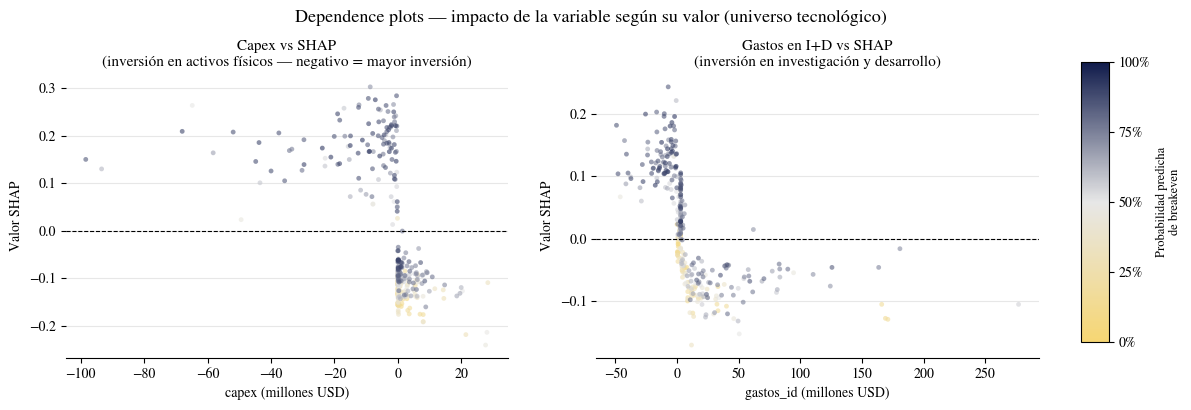

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

vars_dep = ["capex", "gastos_id"]
titulos  = [
    "Capex vs SHAP\n(inversión en activos físicos — negativo = mayor inversión)",
    "Gastos en I+D vs SHAP\n(inversión en investigación y desarrollo)"
]

cmap_dep = LinearSegmentedColormap.from_list(
    "tech_dep", [tech_colors[5], tech_colors[3], tech_colors[0]], N=256
)
norm_dep = Normalize(vmin=0, vmax=1)

for ax, var, titulo in zip(axes, vars_dep, titulos):
    estilo_ax(ax)
    idx_var   = features_con_momentum.index(var)
    x_vals    = X_rf[:, idx_var]
    shap_vals = sv[:, idx_var]

    colores_dep = cmap_dep(norm_dep(df_2024["prob_breakeven"].values))
    p1, p99 = np.nanpercentile(x_vals, [1, 99])
    mask = (x_vals >= p1) & (x_vals <= p99)

    orden  = np.argsort(df_2024["prob_breakeven"].values[mask])
    x_plot = x_vals[mask][orden] / 1e6
    y_plot = shap_vals[mask][orden]
    c_plot = colores_dep[mask][orden]

    ax.scatter(x_plot, y_plot, c=c_plot, alpha=0.6, s=12, linewidths=0)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(titulo, fontfamily=FUENTE, fontsize=11)
    ax.set_xlabel(f"{var} (millones USD)", fontfamily=FUENTE)
    ax.set_ylabel("Valor SHAP", fontfamily=FUENTE)

fig.subplots_adjust(right=0.82, top=0.82)
cax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
sm  = ScalarMappable(cmap=cmap_dep, norm=norm_dep)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("Probabilidad predicha\nde breakeven", fontfamily=FUENTE, fontsize=9)
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"], fontfamily=FUENTE)

fig.suptitle("Dependence plots — impacto de la variable según su valor (universo tecnológico)",
             fontfamily=FUENTE, fontsize=13, y=0.98)
plt.show()

### Interpretación: efecto de umbral en I+D y CAPEX

Los puntos concentrados cerca de cero en el eje horizontal reflejan que
la mayoría de las empresas del universo tecnológico invierten montos
relativamente modestos en I+D y capex en términos absolutos, frente a
un número reducido de empresas de mayor tamaño con inversiones de más
de $100M — una diferencia de escala esperable en un universo que agrupa
empresas de distinto tamaño dentro del rango small/mid-cap.

El patrón relevante está en el eje vertical: dentro de ese grupo de
valores moderados, existe una separación marcada del valor SHAP, entre
fuertemente positivo (+0.2) y fuertemente negativo (-0.15). Esto sugiere
que el modelo no captura una relación proporcional simple ("a mayor
inversión, mayor probabilidad"), sino un efecto más cercano a un
**umbral**: la presencia de inversión no trivial en I+D o capex —más
que su magnitud exacta en dólares— parece ser la señal más discriminante
para distinguir empresas en fase de "pérdida estratégica" de aquellas
en riesgo de deterioro estructural (Campbell et al., 2005).

## 6. Análisis por subsector tecnológico

Aunque el universo está acotado al sector tecnológico, existen diferencias
estructurales entre sus subsectores (software, semiconductores, componentes
electrónicos, equipos de comunicación). Este análisis explora si las
variables predictoras más relevantes difieren entre ellos.

Top 5 subsectores por número de observaciones en 2024:
sector
Services-Prepackaged Software                           109
Semiconductors & Related Devices                         78
Services-Computer Programming, Data Processing, Etc.     37
Services-Computer Integrated Systems Design              31
Services-Computer Processing & Data Preparation          31
Name: count, dtype: int64
  Software: 109 observaciones
  Semicon.: 78 observaciones
  Services-Com: 37 observaciones
  Sist. Integ.: 31 observaciones
  Proc. Datos: 31 observaciones


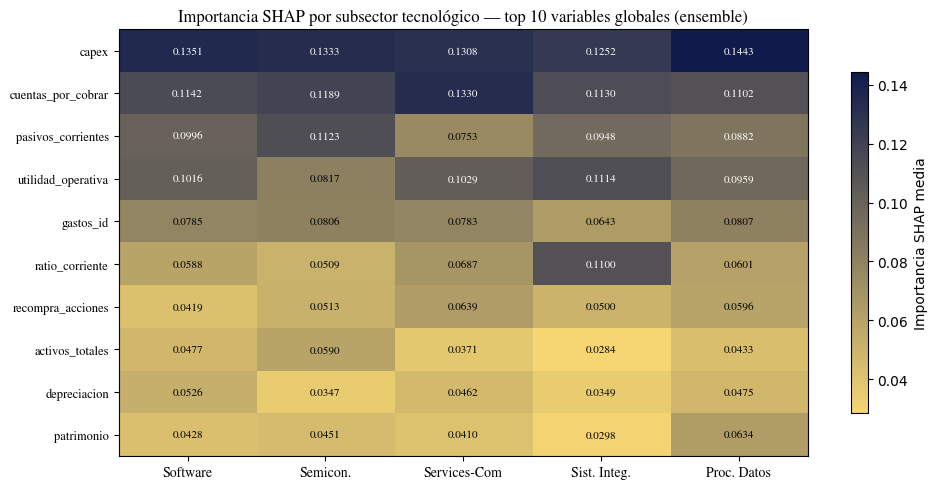

In [13]:
top5_subsectores = df_2024["sector"].value_counts().head(5).index.tolist()
print("Top 5 subsectores por número de observaciones en 2024:")
print(df_2024["sector"].value_counts().head(5))

nombres_cortos = {}
for s in top5_subsectores:
    if "Software" in s:
        nombres_cortos[s] = "Software"
    elif "Semiconductor" in s:
        nombres_cortos[s] = "Semicon."
    elif "Computer Integrated" in s:
        nombres_cortos[s] = "Sist. Integ."
    elif "Computer Processing" in s or "Data Preparation" in s:
        nombres_cortos[s] = "Proc. Datos"
    elif "Communications Equipment" in s:
        nombres_cortos[s] = "Comunicac."
    elif "Electronic Components" in s:
        nombres_cortos[s] = "Componentes"
    else:
        nombres_cortos[s] = s[:12]

top10_vars_sector = importancia_global.head(10).index.tolist()

shap_por_subsector = {}
for sector in top5_subsectores:
    mask = df_2024["sector"].values == sector
    n_obs = mask.sum()
    shap_por_subsector[sector] = pd.Series(
        np.abs(sv[mask]).mean(axis=0),
        index=features_con_momentum
    )
    print(f"  {nombres_cortos[sector]}: {n_obs} observaciones")

matriz_subsector = pd.DataFrame(
    {nombres_cortos[s]: shap_por_subsector[s][top10_vars_sector] for s in top5_subsectores}
)

cmap_heat = LinearSegmentedColormap.from_list(
    "tech", [tech_colors[5], tech_colors[0]], N=256
)

fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(matriz_subsector.values, cmap=cmap_heat, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8, label="Importancia SHAP media")

ax.set_xticks(range(len(matriz_subsector.columns)))
ax.set_yticks(range(len(top10_vars_sector)))
ax.set_xticklabels(matriz_subsector.columns, fontfamily=FUENTE, fontsize=10)
ax.set_yticklabels(top10_vars_sector, fontfamily=FUENTE, fontsize=9)

umbral = matriz_subsector.values.max() * 0.6
for i in range(len(top10_vars_sector)):
    for j in range(len(matriz_subsector.columns)):
        val   = matriz_subsector.values[i, j]
        color = "white" if val > umbral else "black"
        ax.text(j, i, f"{val:.4f}", ha="center", va="center",
                fontsize=8, color=color, fontfamily=FUENTE)

ax.set_title("Importancia SHAP por subsector tecnológico — top 10 variables globales (ensemble)",
             fontfamily=FUENTE, fontsize=12)
plt.tight_layout()
plt.show()

### Interpretación: análisis por subsector

El análisis revela que capex es la señal dominante en todos los
subsectores tecnológicos, con especial relevancia en Procesamiento de
Datos (0.1443) -- consistente con la naturaleza intensiva en
infraestructura de este subsector. En contraste, ratio_corriente (liquidez
de corto plazo) muestra una importancia notablemente mayor en Sistemas
Integrados (0.1100) frente al resto (0.05-0.07), sugiriendo una mayor
dependencia de la solvencia de corto plazo en negocios basados en
proyectos y contratos. Este mismo subsector presenta la menor importancia
relativa de gastos_id (0.0643), reforzando la idea de que Sistemas
Integrados es un modelo de negocio orientado a implementación más que a
investigación y desarrollo propio -- evidencia de que, incluso dentro de
un sector definido como "tecnológico", persisten diferencias estructurales
relevantes entre subsectores.

HITO 4 — Parte 6: Análisis por subsector tecnológico
==================================================================
Fecha: 17/08/2026
Notebook: 04_explicabilidad_tech.ipynb

Qué se hizo:
- Se calculó la importancia SHAP promedio por subsector tecnológico
  (Software, Semiconductores, Services-Communications, Sistemas
  Integrados, Procesamiento de Datos), sobre las top 10 variables
  globales.

Resultado:
- capex lidera en los 5 subsectores, con máxima relevancia en
  Procesamiento de Datos (0.1443).
- ratio_corriente muestra una importancia notablemente superior en
  Sistemas Integrados (0.1100) frente al resto (0.05-0.07).
- gastos_id tiene su menor peso relativo en Sistemas Integrados (0.0643),
  el subsector con mayor dependencia de liquidez.

Importancia:
Evidencia que, incluso dentro del sector tecnológico ya delimitado,
persisten diferencias estructurales en qué variables predicen mejor el
breakeven según el subsector -- particularmente entre subsectores más
intensivos en I+D (software, semiconductores) y aquellos orientados a
servicios/implementación (sistemas integrados), donde la liquidez pesa
más que la inversión en investigación.

## 7. Separación del modelo

Un buen modelo asigna probabilidades altas a las empresas que realmente
alcanzan el breakeven (Y=1) y bajas a las que no (Y=0). Esta sección
cuantifica qué tan bien logra el ensemble separar ambas clases.

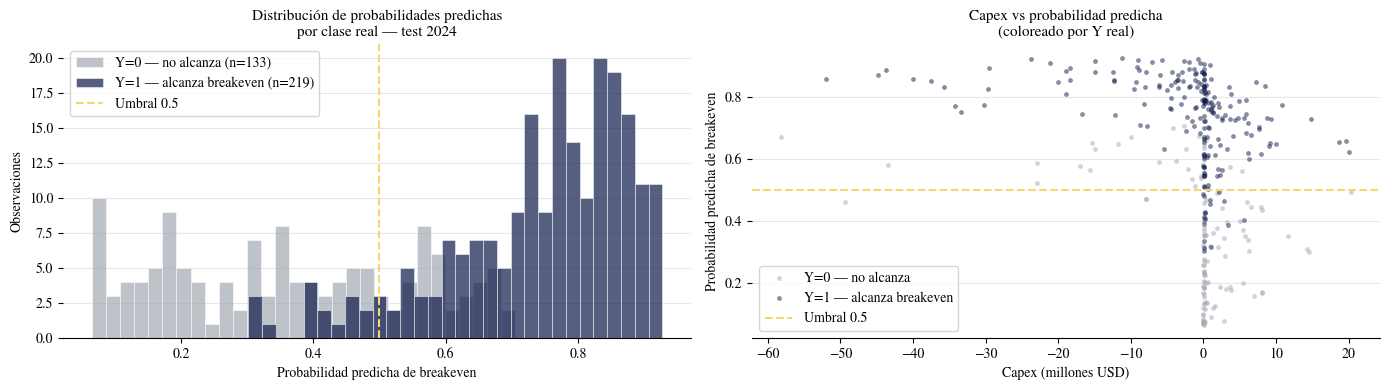

Probabilidad media predicha para empresas que NO alcanzaron breakeven (Y=0): 0.364
Probabilidad media predicha para empresas que SÍ alcanzaron breakeven (Y=1): 0.740
Diferencia: 0.376


In [14]:
prob_y0 = df_2024[df_2024["Y"] == 0]["prob_breakeven"]
prob_y1 = df_2024[df_2024["Y"] == 1]["prob_breakeven"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel izquierdo — histograma de probabilidades por Y real
estilo_ax(axes[0])
axes[0].hist(prob_y0, bins=30, alpha=0.7, color=tech_colors[2],
             label=f"Y=0 — no alcanza (n={len(prob_y0):,})",
             edgecolor="white", linewidth=0.5)
axes[0].hist(prob_y1, bins=30, alpha=0.7, color=tech_colors[0],
             label=f"Y=1 — alcanza breakeven (n={len(prob_y1):,})",
             edgecolor="white", linewidth=0.5)
axes[0].axvline(0.5, color=tech_colors[5], linewidth=1.5,
                linestyle="--", label="Umbral 0.5")
axes[0].set_title("Distribución de probabilidades predichas\npor clase real — test 2024",
                  fontfamily=FUENTE, fontsize=11)
axes[0].set_xlabel("Probabilidad predicha de breakeven", fontfamily=FUENTE)
axes[0].set_ylabel("Observaciones", fontfamily=FUENTE)
axes[0].legend(prop={"family": FUENTE}, fontsize=9)

# Panel derecho — capex vs probabilidad (variable líder en este universo)
estilo_ax(axes[1])
idx_cx = features_con_momentum.index("capex")
cx_vals = X_rf[:, idx_cx] / 1e6
p1, p99 = np.nanpercentile(cx_vals, [2, 98])
mask = (cx_vals >= p1) & (cx_vals <= p99)

y0_mask = mask & (df_2024["Y"].values == 0)
y1_mask = mask & (df_2024["Y"].values == 1)

axes[1].scatter(cx_vals[y0_mask], df_2024["prob_breakeven"].values[y0_mask],
                color=tech_colors[2], alpha=0.5, s=12, linewidths=0,
                label="Y=0 — no alcanza")
axes[1].scatter(cx_vals[y1_mask], df_2024["prob_breakeven"].values[y1_mask],
                color=tech_colors[0], alpha=0.5, s=12, linewidths=0,
                label="Y=1 — alcanza breakeven")
axes[1].axhline(0.5, color=tech_colors[5], linewidth=1.5,
                linestyle="--", label="Umbral 0.5")
axes[1].set_title("Capex vs probabilidad predicha\n(coloreado por Y real)",
                  fontfamily=FUENTE, fontsize=11)
axes[1].set_xlabel("Capex (millones USD)", fontfamily=FUENTE)
axes[1].set_ylabel("Probabilidad predicha de breakeven", fontfamily=FUENTE)
axes[1].legend(prop={"family": FUENTE}, fontsize=9)

plt.tight_layout()
plt.show()

diferencia = prob_y1.mean() - prob_y0.mean()
print(f"Probabilidad media predicha para empresas que NO alcanzaron breakeven (Y=0): {prob_y0.mean():.3f}")
print(f"Probabilidad media predicha para empresas que SÍ alcanzaron breakeven (Y=1): {prob_y1.mean():.3f}")
print(f"Diferencia: {diferencia:.3f}")

HITO 4 — Parte 7: Separación del modelo (ensemble completo)
==================================================================
Fecha: 17/08/2026
Notebook: 04_explicabilidad_tech.ipynb

Qué se hizo:
- Se evaluó la capacidad del ensemble para separar las clases Y=1 y
  Y=0 mediante la distribución de probabilidades predichas sobre las
  352 observaciones completas del fold de test 2024 (133 Y=0, 219 Y=1).

Resultado:
- Probabilidad media predicha para empresas Y=0 (no alcanzan): 0.364
- Probabilidad media predicha para empresas Y=1 (sí alcanzan): 0.740
- Diferencia entre medias: 0.376
- Existe una zona de traslape entre aproximadamente 0.3 y 0.6, donde
  ambas clases coexisten -- la "zona de incertidumbre" del modelo.
- El panel de capex vs. probabilidad confirma el patrón de umbral ya
  identificado: valores de capex distintos de cero (mayor inversión)
  se asocian consistentemente con probabilidades por encima de 0.5.

Importancia:
Confirma, sobre el conjunto completo de test (no solo casos ilustrativos),
que el ensemble logra una separación clara y significativa entre ambas
clases, respaldando cuantitativamente el AUC-PR de 0.783 obtenido en el
Cuaderno 3 con evidencia visual directa de la calidad de las
probabilidades predichas.

## 8. Conclusiones

El análisis de explicabilidad realizado en este cuaderno —combinando
importancia SHAP y Gini, casos individuales, dependence plots y un
desglose por subsector— converge en un hallazgo central: **la inversión
activa en infraestructura (capex) e investigación y desarrollo
(gastos_id) constituye la señal dominante de transición hacia el
breakeven operativo en empresas tecnológicas**, por encima de variables
que en el análisis multisectorial original resultaban más determinantes,
como el historial acumulado de rentabilidad.

La coincidencia entre SHAP y Gini en el Top 5 de variables (capex,
cuentas_por_cobrar, pasivos_corrientes, utilidad_operativa, gastos_id)
da robustez metodológica a este hallazgo, reforzada por el análisis de
casos individuales: empresas como AIOT, ALGM y AMBA —que sí alcanzaron
breakeven— muestran consistentemente valores SHAP positivos en capex y
gastos_id, mientras que empresas como RGTI, SOUN y TCX —que no lo
alcanzaron— muestran el patrón inverso.

Los dependence plots revelan que el efecto de estas variables no es
proporcional sino más cercano a un umbral: lo que distingue a las
empresas no es tanto *cuánto* invierten en I+D o capex, sino si invierten
de forma no trivial o prácticamente nada. Este patrón es coherente con
la distinción teórica entre pérdidas estratégicas y pérdidas estructurales
(Campbell et al., 2005) que sustenta esta investigación.

Finalmente, el análisis por subsector muestra que, incluso dentro de un
universo ya delimitado como "tecnológico", persisten diferencias
estructurales relevantes: Sistemas Integrados depende mucho más de la
liquidez de corto plazo (ratio_corriente) que del gasto en I+D, a
diferencia de Software y Semiconductores. Esto sugiere que futuras
extensiones de este trabajo podrían explorar modelos aún más granulares
a nivel de subsector.

En conjunto, estos hallazgos validan empíricamente la recomendación del
asesor de tesis de desarrollar un modelo sectorialmente específico: la
relevancia predictiva de cada variable financiera —y en particular de
la inversión en I+D— no es universal, sino que depende de la estructura
económica particular del sector analizado. La capacidad del ensemble
para separar ambas clases (probabilidad media de 0.740 para empresas
que alcanzan breakeven vs. 0.364 para las que no) confirma, además, que
este comportamiento diferenciado se traduce en una capacidad predictiva
genuina y no solo en un patrón descriptivo.